<a href="https://colab.research.google.com/github/whoisndu/Harvard-MATH-142-Assignments/blob/main/tutorial_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Tutorial
Created by Marc Deisenroth\
Edited by Kris Lokere

The purpose of this notebook is to practice implementing some linear algebra (equations provided) and to explore some properties of linear regression.

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

We consider a linear regression problem of the form
$$
y = \boldsymbol x^T\boldsymbol\theta + \epsilon\,,\quad \epsilon \sim N(0, \sigma^2)
$$
where $\boldsymbol x\in\mathbb{R}^D$ are inputs and $y\in\mathbb{R}$ are noisy observations. The parameter vector $\boldsymbol\theta\in\mathbb{R}^D$ parametrizes the function.

We assume we have a training set $(\boldsymbol x_n, y_n)$, $n=1,\ldots, N$. We summarize the sets of training inputs in $X = \{\boldsymbol x_1, \ldots, \boldsymbol x_N\}$ and corresponding training targets $Y = \{y_1, \ldots, y_N\}$, respectively.

In this tutorial, we are interested in finding good parameters $\boldsymbol\theta$.

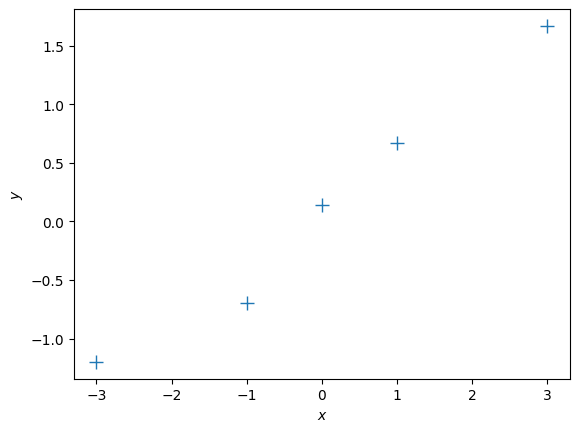

In [2]:
# Define training set
X = np.array([-3, -1, 0, 1, 3]).reshape(-1,1) # 5x1 vector, N=5, D=1
y = np.array([-1.2, -0.7, 0.14, 0.67, 1.67]).reshape(-1,1) # 5x1 vector

# Plot the training set
plt.figure()
plt.plot(X, y, '+', markersize=10)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

## 1. Maximum Likelihood
We will start with maximum likelihood estimation of the parameters $\boldsymbol\theta$. In maximum likelihood estimation, we find the parameters $\boldsymbol\theta^{\mathrm{ML}}$ that maximize the likelihood
$$
p( Y |  X, \boldsymbol\theta) = \prod_{n=1}^N p(y_n | \boldsymbol x_n, \boldsymbol\theta)\,.
$$
From the lecture we know that the maximum likelihood estimator is given by
$$
\boldsymbol\theta^{\text{ML}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y\in\mathbb{R}^D\,,
$$
where
$$
\boldsymbol X = [\boldsymbol x_1, \ldots, \boldsymbol x_N]^T\in\mathbb{R}^{N\times D}\,,\quad \boldsymbol y = [y_1, \ldots, y_N]^T \in\mathbb{R}^N\,.
$$

Let us compute the maximum likelihood estimate for a given training set

In [3]:
## EDIT THIS FUNCTION
def max_lik_estimate(X, y):

    # X: N x D matrix of training inputs
    # y: N x 1 vector of training targets/observations
    # returns: maximum likelihood parameters (D x 1)

    N, D = X.shape
    theta_ml = np.linalg.solve(X.T @ X, X.T @ y) ## <-- EDIT THIS LINE
    return theta_ml

In [4]:
# get maximum likelihood estimate
theta_ml = max_lik_estimate(X,y)
theta_ml

array([[0.499]])

Now, make a prediction using the maximum likelihood estimate that we just found

In [5]:
## EDIT THIS FUNCTION
def predict_with_estimate(Xtest, theta):

    # Xtest: K x D matrix of test inputs
    # theta: D x 1 vector of parameters
    # returns: prediction of f(Xtest); K x 1 vector

    prediction = Xtest @ theta ## <-- EDIT THIS LINE

    return prediction

Now, let's see whether we got something useful:

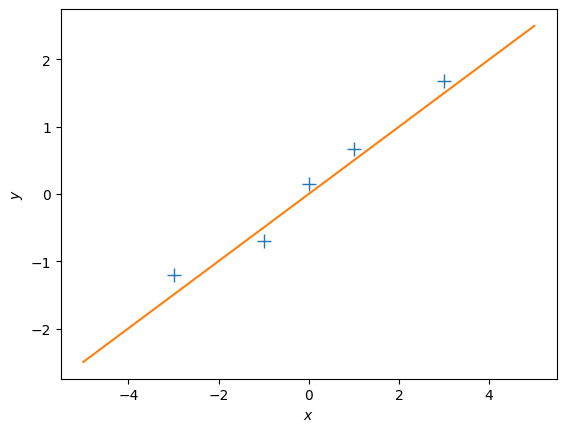

In [6]:
# define a test set
Xtest = np.linspace(-5,5,100).reshape(-1,1) # 100 x 1 vector of test inputs

# predict the function values at the test points using the maximum likelihood estimator
ml_prediction = predict_with_estimate(Xtest, theta_ml)

# plot
plt.figure()
plt.plot(X, y, '+', markersize=10)
plt.plot(Xtest, ml_prediction)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

#### Questions
1. Does the solution above look reasonable?

* Yes - the line passes through the data with slope ~0.5, which matches the visual trend.

2. Play around with different values of $\theta$. How do the corresponding functions change?

* Changing $\theta$ rotates the line since the model is y = x *$\theta$ with no intercept.
Larger $\theta$ = steeper, smaller $\theta$ = flatter.

3. Modify the training targets $Y$ and re-run your computation. What changes?

* Adding to Y shifts the data up, subtracting shifts it down. Small changes to Y would hardly move theta_ml because the model is forced through the origin and the MLE just finds the best slope through zero regardless of the vertical shift

Let us now look at a different training set, where we add 2.0 to every $y$-value, and compute the maximum likelihood estimate

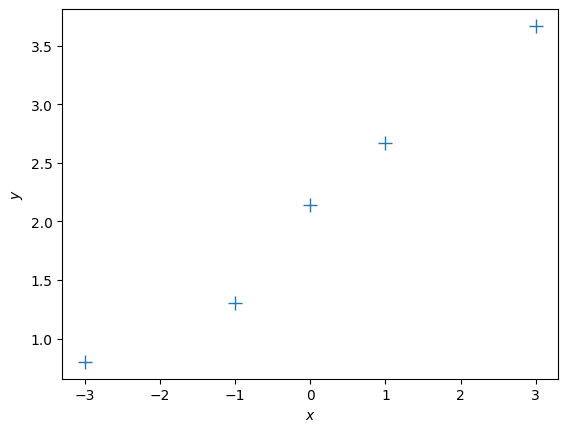

In [7]:
ynew = y + 2.0

plt.figure()
plt.plot(X, ynew, '+', markersize=10)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

[[0.499]]


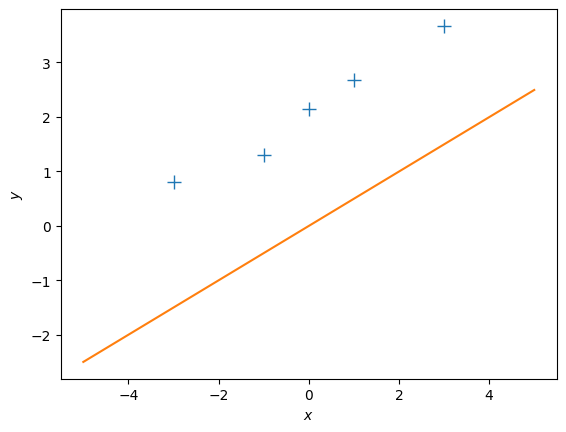

In [8]:
# get maximum likelihood estimate
theta_ml = max_lik_estimate(X, ynew)
print(theta_ml)

# define a test set
Xtest = np.linspace(-5,5,100).reshape(-1,1) # 100 x 1 vector of test inputs

# predict the function values at the test points using the maximum likelihood estimator
ml_prediction = predict_with_estimate(Xtest, theta_ml)

# plot
plt.figure()
plt.plot(X, ynew, '+', markersize=10)
plt.plot(Xtest, ml_prediction)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

#### Question:
1. This maximum likelihood estimate doesn't look too good: The orange line is too far away from the observations although we just shifted them by 2. Why is this the case?

* The line is poor because the model y = x*$\theta$ has no intercept term, so it is forced through the origin (0,0). Shifting y up by 2 moves all the data above the origin but the line cannot follow - it is stuck rotating around zero.

2. How can we fix this problem?

* We can fix this by adding an intercept term, making the model y = x*$\theta$ + b.
This gives the line a free vertical position so it can shift up to meet the data.
This can ideally be achieved by augmenting X with a column of ones.

Let us now define a linear regression model that is slightly more flexible:
$$
y = \theta_0 + \boldsymbol x^T \boldsymbol\theta_1 + \epsilon\,,\quad \epsilon\sim N(0,\sigma^2)
$$
Here, we added an offset (bias) parameter $\theta_0$ to our original model.

#### Question:
1. What is the effect of this bias parameter, i.e., what additional flexibility does it offer?

* The bias parameter theta_0 allows the line to shift vertically off the origin.
Without it the model is forced through (0,0). With it the line can sit at any vertical position, making it flexible enough to fit data that doesn't pass through zero - like the shifted ynew = y + 2.0 from before.

If we now define the inputs to be the augmented vector $\boldsymbol x_{\text{aug}} = \begin{bmatrix}1\\\boldsymbol x\end{bmatrix}$, we can write the new linear regression model as
$$
y = \boldsymbol x_{\text{aug}}^T\boldsymbol\theta_{\text{aug}} + \epsilon\,,\quad \boldsymbol\theta_{\text{aug}} = \begin{bmatrix}
\theta_0\\
\boldsymbol\theta_1
\end{bmatrix}\,.
$$

In [9]:
N, D = X.shape
X_aug = np.hstack([np.ones((N,1)), X]) # augmented training inputs of size N x (D+1)
theta_aug = np.zeros((D+1, 1)) # new theta vector of size (D+1) x 1

In [10]:
X_aug

array([[ 1., -3.],
       [ 1., -1.],
       [ 1.,  0.],
       [ 1.,  1.],
       [ 1.,  3.]])

Let us now compute the maximum likelihood estimator for this setting.
_Hint:_ If possible, re-use code that you have already written

In [11]:
## EDIT THIS FUNCTION
def max_lik_estimate_aug(X_aug, y):

    theta_aug_ml = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)  ## <-- EDIT THIS LINE

    return theta_aug_ml

In [12]:
theta_aug_ml = max_lik_estimate_aug(X_aug, ynew) ## <-- This needs to change to reflect the fix in the plotted cell below.
## theta_aug_ml = max_lik_estimate_aug(X_aug, y) <-- Previous line
theta_aug_ml

array([[2.116],
       [0.499]])

Now, we can make predictions again:

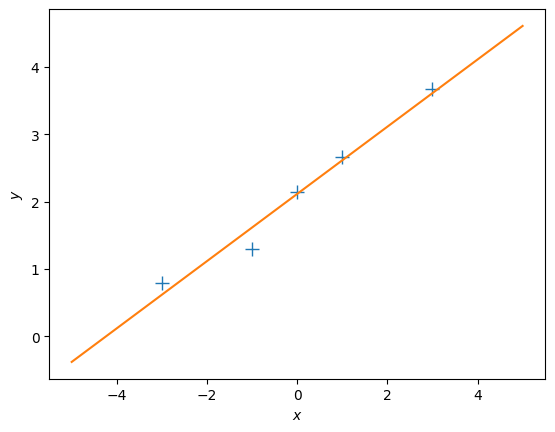

In [13]:
# define a test set (we also need to augment the test inputs with ones)
Xtest_aug = np.hstack([np.ones((Xtest.shape[0],1)), Xtest]) # 100 x (D + 1) vector of test inputs

# predict the function values at the test points using the maximum likelihood estimator
ml_prediction = predict_with_estimate(Xtest_aug, theta_aug_ml)

# plot
plt.figure()
plt.plot(X, ynew, '+', markersize=10)
plt.plot(Xtest, ml_prediction)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

It seems this has solved our problem!
#### Question:
1. Play around with the first parameter of $\boldsymbol\theta_{\text{aug}}$ and see how the fit of the function changes.

* The first parameter of $\boldsymbol\theta_{\text{aug}}$ is the intercept $\theta_0$.
Changing it shifts the line up or down vertically without affecting the slope.
A larger value moves the line up, a smaller value moves it down.

2. Play around with the second parameter of $\boldsymbol\theta_{\text{aug}}$ and see how the fit of the function changes.

* The second parameter of $\boldsymbol\theta_{\text{aug}}$ is the slope $\theta_1$.
Changing it rotates the line around the intercept. A larger value makes the line steeper, a smaller value makes it flatter. This is the same effect as changing $\theta$ in the original model without the bias term.

### Nonlinear Features
So far, we have looked at linear regression with linear features. This allowed us to fit straight lines. However, linear regression also allows us to fit functions that are nonlinear in the inputs $\boldsymbol x$, as long as the parameters $\boldsymbol\theta$ appear linearly. This means, we can learn functions of the form
$$
f(\boldsymbol x, \boldsymbol\theta) = \sum_{k = 1}^K \theta_k \phi_k(\boldsymbol x)\,,
$$
where the features $\phi_k(\boldsymbol x)$ are (possibly nonlinear) transformations of the inputs $\boldsymbol x$.

Let us have a look at an example where the observations clearly do not lie on a straight line:

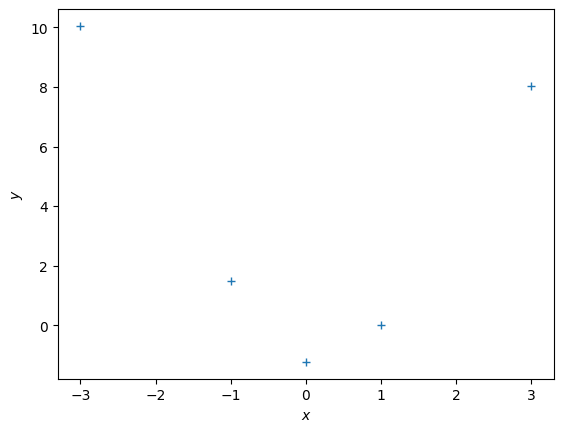

In [14]:
y = np.array([10.05, 1.5, -1.234, 0.02, 8.03]).reshape(-1,1)
plt.figure()
plt.plot(X, y, '+')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

#### Polynomial Regression
One class of functions that is covered by linear regression is the family of polynomials because we can write a polynomial of degree $K$ as
$$
\sum_{k=0}^K \theta_k x^k = \boldsymbol \phi(x)^T\boldsymbol\theta\,,\quad
\boldsymbol\phi(x)=
\begin{bmatrix}
x^0\\
x^1\\
\vdots\\
x^K
\end{bmatrix}\in\mathbb{R}^{K+1}\,.
$$
Here, $\boldsymbol\phi(x)$ is a nonlinear feature transformation of the inputs $x\in\mathbb{R}$.

Similar to the earlier case we can define a matrix that collects all the feature transformations of the training inputs:
$$
\boldsymbol\Phi = \begin{bmatrix}
\boldsymbol\phi(x_1) & \boldsymbol\phi(x_2) & \cdots & \boldsymbol\phi(x_n)
\end{bmatrix}^T \in\mathbb{R}^{N\times K+1}
$$

Let us start by computing the feature matrix $\boldsymbol \Phi$

In [15]:
## EDIT THIS FUNCTION
def poly_features(X, K):

    # X: inputs of size N x 1
    # K: degree of the polynomial
    # computes the feature matrix Phi (N x (K+1))

    X = X.flatten()
    N = X.shape[0]

    #initialize Phi
    Phi = np.zeros((N, K+1))

    # Compute the feature matrix in stages
    Phi = np.column_stack([X**k for k in range(K+1)])  ## <--- EDIT THIS LINE
    return Phi

In [16]:
# try out the Phi(x) function:
K=2
Phi = poly_features(X, K)
print(X)
print(Phi)

[[-3]
 [-1]
 [ 0]
 [ 1]
 [ 3]]
[[ 1 -3  9]
 [ 1 -1  1]
 [ 1  0  0]
 [ 1  1  1]
 [ 1  3  9]]


With this feature matrix we get the maximum likelihood estimator as
$$
\boldsymbol \theta^\text{ML} = (\boldsymbol\Phi^T\boldsymbol\Phi)^{-1}\boldsymbol\Phi^T\boldsymbol y
$$
For reasons of numerical stability, we often add a small diagonal "jitter" $\kappa>0$ to $\boldsymbol\Phi^T\boldsymbol\Phi$ so that we can invert the matrix without significant problems so that the maximum likelihood estimate becomes
$$
\boldsymbol \theta^\text{ML} = (\boldsymbol\Phi^T\boldsymbol\Phi + \kappa\boldsymbol I)^{-1}\boldsymbol\Phi^T\boldsymbol y
$$

In [17]:
## EDIT THIS FUNCTION
def nonlinear_features_maximum_likelihood(Phi, y):
    # Phi: features matrix for training inputs. Size of N x D
    # y: training targets. Size of N by 1
    # returns: maximum likelihood estimator theta_ml. Size of D x 1

    kappa = 1e-08 # 'jitter' term; good for numerical stability

    D = Phi.shape[1]

    # maximum likelihood estimate
    theta_ml = np.linalg.solve(Phi.T @ Phi + kappa * np.eye(D), Phi.T @ y)  ## <--- EDIT THIS LINE

    return theta_ml

Now we have all the ingredients together: The computation of the feature matrix and the computation of the maximum likelihood estimator for polynomial regression. Let's see how this works.

To make predictions at test inputs $\boldsymbol X_{\text{test}}\in\mathbb{R}$, we need to compute the features (nonlinear transformations) $\boldsymbol\Phi_{\text{test}}= \boldsymbol\phi(\boldsymbol X_{\text{test}})$ of $\boldsymbol X_{\text{test}}$ to give us the predicted mean
$$
\mathbb{E}[\boldsymbol y_{\text{test}}] = \boldsymbol \Phi_{\text{test}}\boldsymbol\theta^{\text{ML}}
$$

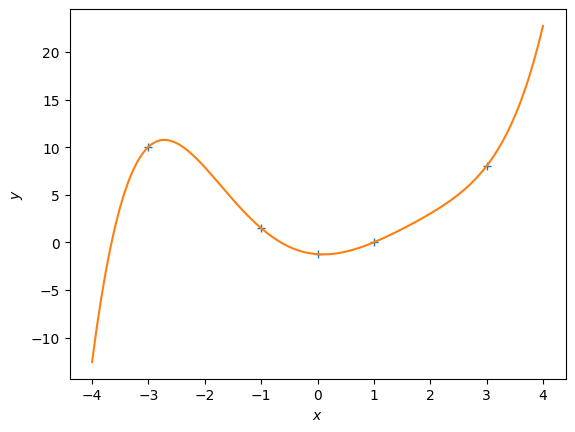

In [18]:
K = 5 # Define the degree of the polynomial we wish to fit
Phi = poly_features(X, K) # N x (K+1) feature matrix

theta_ml = nonlinear_features_maximum_likelihood(Phi, y) # maximum likelihood estimator

# test inputs
Xtest = np.linspace(-4,4,100).reshape(-1,1)

# feature matrix for test inputs
Phi_test = poly_features(Xtest, K)

y_pred = Phi_test @ theta_ml # predicted y-values

plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, y_pred)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

Experiment with different polynomial degrees in the code above.
#### Questions:
1. What do you observe?

* Low degrees (K=1,2) underfit - the polynomial is too simple to capture the curve in the data. High degrees (K=7+) overfit - the polynomial chases every data point and becomes wildly unstable outside the training range. As K increases the curve becomes increasingly erratic especially at the edges.


2. What is a good fit?

* K=5 appears to be a good fit for this dataset - the curve passes close to all
data points without becoming unstable. Generally a good fit is one that captures the underlying trend without overfitting to the noise in the training data.


## Evaluating the Quality of the Model

Let us have a look at a more interesting data set

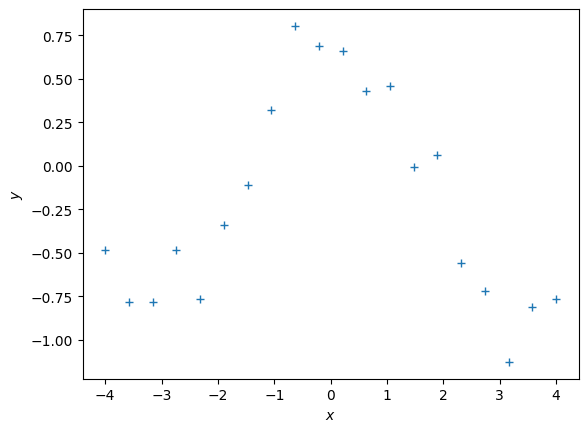

In [19]:
def f(x):
    return np.cos(x) + 0.2*np.random.normal(size=(x.shape))

X = np.linspace(-4,4,20).reshape(-1,1)
y = f(X)

plt.figure()
plt.plot(X, y, '+')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

Now, let us use the work from above and fit polynomials to this dataset.

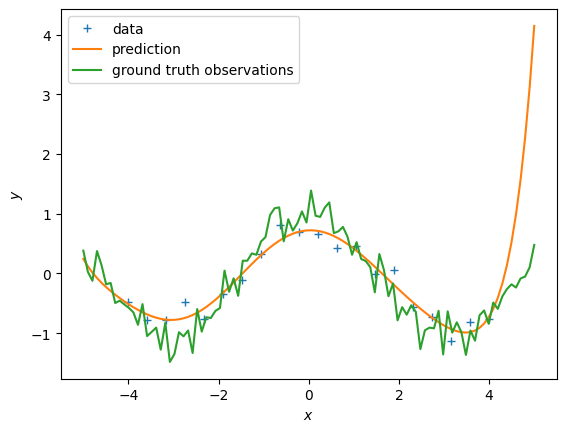

In [20]:
## EDIT THIS CELL
K = 8 # Define the degree of the polynomial we wish to fit <-- 2 seemed to underfit

Phi = poly_features(X, K) # N x (K+1) feature matrix

theta_ml = nonlinear_features_maximum_likelihood(Phi, y) # maximum likelihood estimator

# test inputs
Xtest = np.linspace(-5,5,100).reshape(-1,1)
ytest = f(Xtest) # ground-truth y-values

# feature matrix for test inputs
Phi_test = poly_features(Xtest, K)

y_pred = Phi_test @ theta_ml  # <-- EDIT THIS LINE

# plot
plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, y_pred)
plt.plot(Xtest, ytest)
plt.legend(["data", "prediction", "ground truth observations"])
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

#### Questions:
1. Try out different degrees of polynomials.

* Low degrees (K=1,2,3) underfit - too simple to capture the cosine shape.
K=8 fits well within the training range, tracking the cosine shape closely
without chasing noise. K=9+ starts to overfit - the curve becomes unstable
especially at the edges beyond the training range.

2. Based on visual inspection, what looks like the best fit?
* K=8 appears to be the best fit - it captures the underlying cosine shape
across the training range without overfitting to the noise in the data.

Let us now look at a more systematic way to assess the quality of the polynomial that we are trying to fit. For this, we compute the root-mean-squared-error (RMSE) between the $y$-values predicted by our polynomial and the ground-truth $y$-values. The RMSE is then defined as
$$
\text{RMSE} = \left(\frac{1}{N}\sum_{n=1}^N(y_n - y_n^\text{pred})^2\right)^{\frac{1}{2}}
$$
Write a function that computes the RMSE.

In [21]:
## EDIT THIS FUNCTION
def RMSE(y, ypred):
    rmse = np.sqrt(np.mean((y - ypred)**2))  ## <--- EDIT THIS LINE
    return rmse

Now compute the RMSE for different degrees of the polynomial we want to fit.

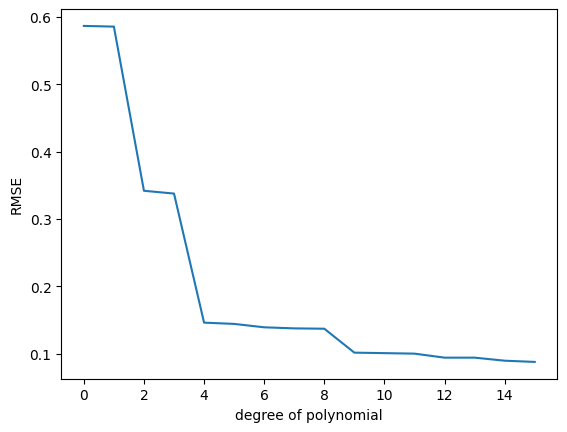

In [22]:
## EDIT THIS CELL
K_max = 15
rmse_train = np.zeros((K_max+1,))

for k in range(K_max+1):
    # WRITE CODE HERE TO MAKE PREDICTIONS AND CALCULATE RMSE

   # feature matrix
   Phi = poly_features(X, k)  ## <-- EDIT THIS LINE

   # maximum likelihood estimate
   theta_ml = nonlinear_features_maximum_likelihood(Phi, y)  ## <-- EDIT THIS LINE

   # predict y-values of training set
   ypred_train = Phi @ theta_ml  ## <-- EDIT THIS LINE

   # RMSE on training set
   rmse_train[k] = RMSE(y, ypred_train)  # <-- EDIT THIS LINE


plt.figure()
plt.plot(rmse_train)
plt.xlabel("degree of polynomial")
plt.ylabel("RMSE")
plt.show()

#### Question:
1. What do you observe?

* Training RMSE decreases as K increases - the higher the degree,
the better the polynomial fits the training data. This makes sense because more
parameters give the model more flexibility to fit the training points exactly.

2. What is the best polynomial fit according to this plot?

* According to this plot alone K=15 looks best since it brings RMSE closest to 0, however in some sense that is an overkill, a model
that perfectly fits training data is not necessarily a good model, its just a model that overfits after memorising the training data.

3. Write some code that plots the function that uses the best polynomial degree (use the test set for this plot). What do you observe now?

* The model would overfit





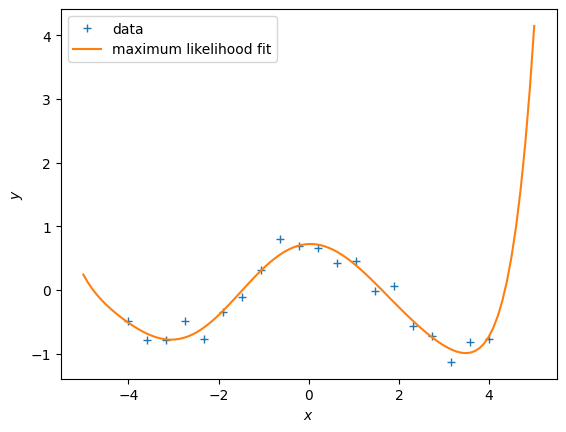

In [23]:
## EDIT THIS CELL

# calculate predicted y values on test
K = 8  # best polynomial degree
Phi_test = poly_features(Xtest, K)
theta_ml = nonlinear_features_maximum_likelihood(poly_features(X, K), y)
ypred_test = Phi_test @ theta_ml    ## <--- EDIT THIS LINE (hint: you may require a few lines to do the computation)


# plot fitted polynomial
plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, ypred_test)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(["data", "maximum likelihood fit"])
plt.show()

The RMSE on the training data is somewhat misleading, because we are interested in the generalization performance of the model. Therefore, we are going to compute the RMSE on the test set and use this to choose a good polynomial degree.

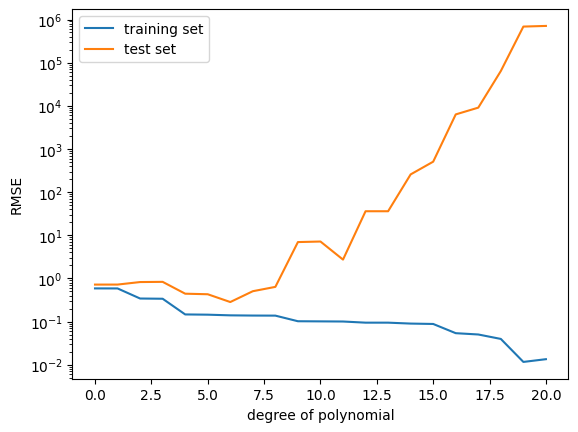

In [24]:
## EDIT THIS CELL
K_max = 20
rmse_train = np.zeros((K_max+1,))
rmse_test = np.zeros((K_max+1,))

for k in range(K_max+1):

    # feature matrix
    Phi = poly_features(X, k)  ## <---- EDIT THIS LINE

    # maximum likelihood estimate
    theta_ml = nonlinear_features_maximum_likelihood(Phi, y)  ## <---- EDIT THIS LINE

    # predict y-values of training set
    ypred_train = Phi @ theta_ml  ## <---- EDIT THIS LINE

    # RMSE on training set
    rmse_train[k] = RMSE(y, ypred_train)  ## <---- EDIT THIS LINE

    # feature matrix for test inputs
    Phi_test = poly_features(Xtest, k)  ## <---- EDIT THIS LINE

    # prediction (test set)
    ypred_test = Phi_test @ theta_ml  ## <---- EDIT THIS LINE

    # RMSE on test set
    rmse_test[k] = RMSE(ytest, ypred_test)  ## <---- EDIT THIS LINE


plt.figure()
plt.semilogy(rmse_train) # this plots the RMSE on a logarithmic scale
plt.semilogy(rmse_test) # this plots the RMSE on a logarithmic scale
plt.xlabel("degree of polynomial")
plt.ylabel("RMSE")
plt.legend(["training set", "test set"])
plt.show()

#### Questions:
1. What do you observe now?

* Training RMSE decreases as K increases, but test RMSE has a
clear minimum at K=8 before exploding upward. The two curves diverge sharply
beyond K=8, revealing that high degree polynomials overfit the training data.

2. Why does the RMSE for the test set not always go down?

* Test RMSE does not always go down because beyond K=8 the model starts memorising the noise in the training data rather than figuring out the underlying cosine pattern. When applied to unseen test points it performs poorly because the noise it memorised was specific to the training set and does not generalise.

3. Which polynomial degree would you choose now?
* K=8 - it is where test RMSE is lowest, confirming earlier visual inspection.

4. Plot the fit for the "best" polynomial degree.
* See above





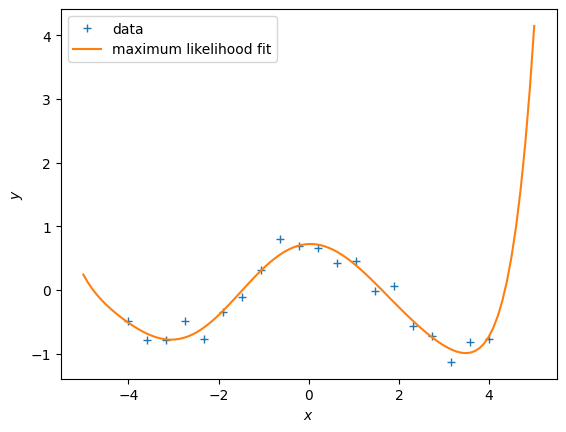

In [25]:
## EDIT THIS CELL

# calculate predicted y values on test data
K = 8  # best polynomial degree
Phi_test = poly_features(Xtest, K)
theta_ml = nonlinear_features_maximum_likelihood(poly_features(X, K), y)
ypred_test = Phi_test @ theta_ml  ## <--- EDIT THIS LINE (hint: you may require a few lines to do the computation)
# ypred_test = Xtest*0 ## <--- EDIT THIS LINE (hint: you may require a few lines to do the computation)

# plot fitted polynomial
plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, ypred_test)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(["data", "maximum likelihood fit"])
plt.show()

#### Question
If you did not have a designated test set, what could you do to estimate the generalization error (purely using the training set)?

* If no test set is available, cross-validation can be used to estimate generalisation error. The training set is split into k folds - the model is trained on k-1 folds and evaluated on the remaining fold. This is repeated k times so every fold acts as a validation set once. The average RMSE across all folds gives an estimate of how well the model generalises to unseen data, without needing a separate test set.

## 2. Maximum A Posteriori Estimation

We are still considering the model
$$
y = \boldsymbol\phi(\boldsymbol x)^T\boldsymbol\theta + \epsilon\,,\quad \epsilon\sim N(0,\sigma^2)\,.
$$
We assume that the noise variance $\sigma^2$ is known.

Instead of maximizing the likelihood, we can look at the maximum of the posterior distribution on the parameters $\boldsymbol\theta$, which is given as
$$
p(\boldsymbol\theta| X,  Y) = \frac{p( Y| X, \boldsymbol\theta)\overbrace{p(\boldsymbol\theta)}^{\text{prior}}}{\underbrace{p( Y| X)}_{\text{evidence}}}
$$
The purpose of the parameter prior $p(\boldsymbol\theta)$ is to discourage the parameters to attain extreme values, a sign that the model overfits. The prior allows us to specify a "reasonable" range of parameter values. Typically, we choose a Gaussian prior $ N(\boldsymbol 0, \alpha^2\boldsymbol I)$, centered at $\boldsymbol 0$ with variance $\alpha^2$ along each parameter dimension.

The MAP estimate of the parameters is
$$
\boldsymbol\theta^{\text{MAP}} = (\boldsymbol\Phi^T\boldsymbol\Phi + \frac{\sigma^2}{\alpha^2}\boldsymbol I)^{-1}\boldsymbol\Phi^T\boldsymbol y
$$
where $\sigma^2$ is the variance of the noise.

In [26]:
## EDIT THIS FUNCTION
def map_estimate_poly(Phi, y, sigma, alpha):
    # Phi: training inputs, Size of N x D
    # y: training targets, Size of D x 1
    # sigma: standard deviation of the noise
    # alpha: standard deviation of the prior on the parameters
    # returns: MAP estimate theta_map, Size of D x 1

    D = Phi.shape[1]

    theta_map = np.linalg.solve(Phi.T @ Phi + (sigma**2 / alpha**2) * np.eye(D), Phi.T @ y)  ## <-- EDIT THIS LINE

    return theta_map

In [27]:
# define the function we wish to estimate later
def g(x, sigma):
    p = np.hstack([x**0, x**1, np.sin(x)])
    w = np.array([-1.0, 0.1, 1.0]).reshape(-1,1)
    return p @ w + sigma*np.random.normal(size=x.shape)

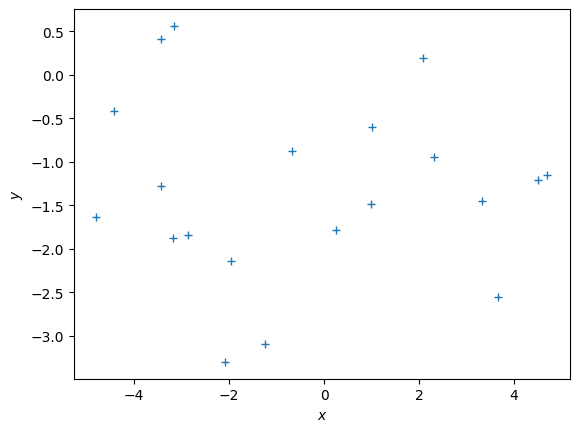

In [28]:
# Generate some data
sigma = 1.0 # noise standard deviation
alpha = 1.0 # standard deviation of the parameter prior
N = 20

np.random.seed(42)

X = (np.random.rand(N)*10.0 - 5.0).reshape(-1,1)
y = g(X, sigma) # training targets

plt.figure()
plt.plot(X, y, '+')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

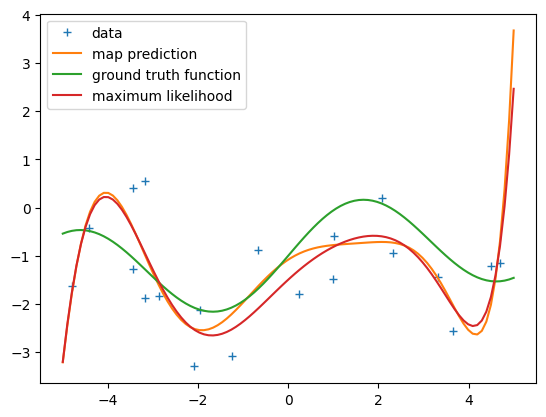

In [29]:
# get the MAP estimate
K = 8 # polynomial degree


# feature matrix
Phi = poly_features(X, K)

theta_map = map_estimate_poly(Phi, y, sigma, alpha)

# maximum likelihood estimate
theta_ml = nonlinear_features_maximum_likelihood(Phi, y)

Xtest = np.linspace(-5,5,100).reshape(-1,1)
ytest = g(Xtest, sigma)

Phi_test = poly_features(Xtest, K)
y_pred_map = Phi_test @ theta_map

y_pred_mle = Phi_test @ theta_ml

plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, y_pred_map)
plt.plot(Xtest, g(Xtest, 0))
plt.plot(Xtest, y_pred_mle)

plt.legend(["data", "map prediction", "ground truth function", "maximum likelihood"])
plt.show()

In [30]:
print(np.hstack([theta_ml, theta_map]))

[[-1.49712990e+00 -1.08154986e+00]
 [ 8.56868912e-01  6.09177023e-01]
 [-1.28335730e-01 -3.62071208e-01]
 [-7.75319509e-02 -3.70531732e-03]
 [ 3.56425467e-02  7.43090617e-02]
 [-4.11626749e-03 -1.03278646e-02]
 [-2.48817783e-03 -4.89363010e-03]
 [ 2.70146690e-04  4.24148554e-04]
 [ 5.35996050e-05  1.03384719e-04]]


Now, let us compute the RMSE for different polynomial degrees and see whether the MAP estimate addresses the overfitting issue we encountered with the maximum likelihood estimate.

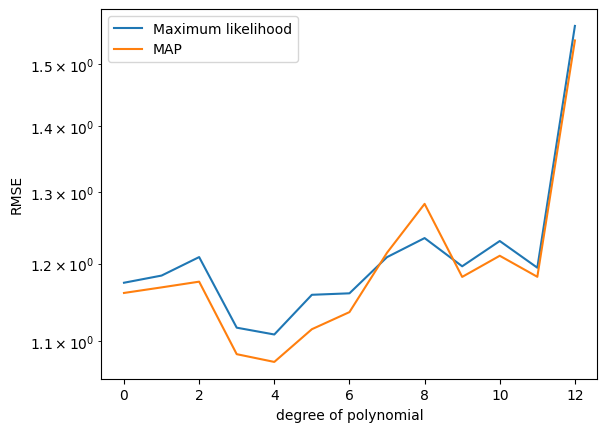

In [31]:
## EDIT THIS CELL

K_max = 12 # this is the maximum degree of polynomial we will consider
assert(K_max < N) # this is the latest point when we'll run into numerical problems

rmse_mle = np.zeros((K_max+1,))
rmse_map = np.zeros((K_max+1,))

for k in range(K_max+1):

    # MLE
    Phi = poly_features(X, k)
    theta_ml = nonlinear_features_maximum_likelihood(Phi, y)
    Phi_test = poly_features(Xtest, k)
    ypred_mle = Phi_test @ theta_ml
    rmse_mle[k] = RMSE(ytest, ypred_mle)  ## Compute the maximum likelihood estimator, compute the test-set predictions, compute the RMSE

    # MAP
    theta_map = map_estimate_poly(Phi, y, sigma, alpha)
    ypred_map = Phi_test @ theta_map
    rmse_map[k] = RMSE(ytest, ypred_map)  ## Compute the MAP estimator, compute the test-set predictions, compute the RMSE

plt.figure()
plt.semilogy(rmse_mle) # this plots the RMSE on a logarithmic scale
plt.semilogy(rmse_map) # this plots the RMSE on a logarithmic scale
plt.xlabel("degree of polynomial")
plt.ylabel("RMSE")
plt.legend(["Maximum likelihood", "MAP"])
plt.show()

#### Questions:
1. What do you observe?

* MAP (orange) consistently achieves lower or equal test RMSE compared to MLE (blue) across most polynomial degrees. Both curves rise sharply at K=12, but MAP stays slightly below MLE throughout, confirming that the prior is helping regularise the model and reduce overfitting. The best K appears to be around K=4 for both.

2. What is the influence of the prior variance on the parameters ($\alpha^2$)? Change the parameter and describe what happens.

* alpha controls how much the prior pulls the parameters toward zero:
- Small alpha (e.g. 0.1): strong prior, parameters are heavily constrained,
MAP tracks the ground truth function closely and remains stable at the edges. At alpha=0.1 the prior is so restrictive that it prevents the parameters from growing large enough to fit the higher degree polynomial terms. So while MLE freely uses all K=8 parameters to get a better fit, MAP is being held back by the prior saying "keep your parameters small".

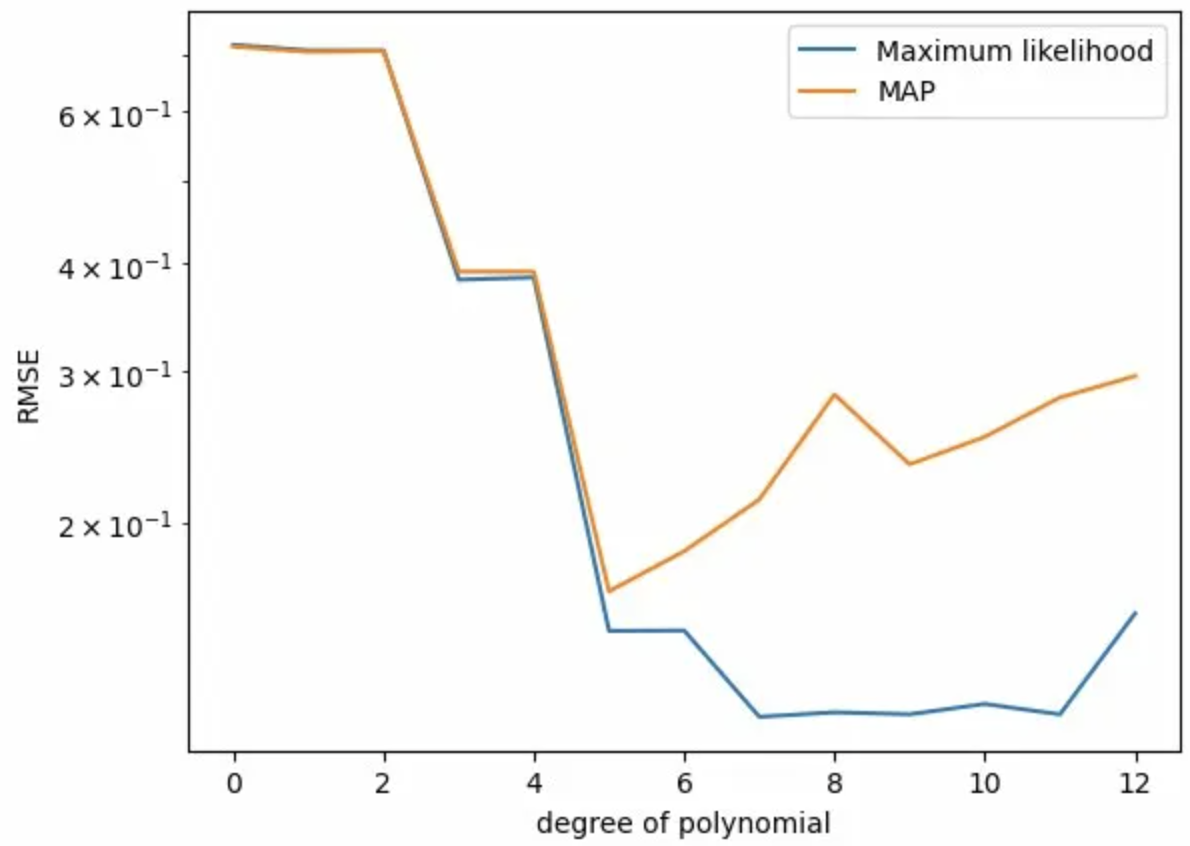
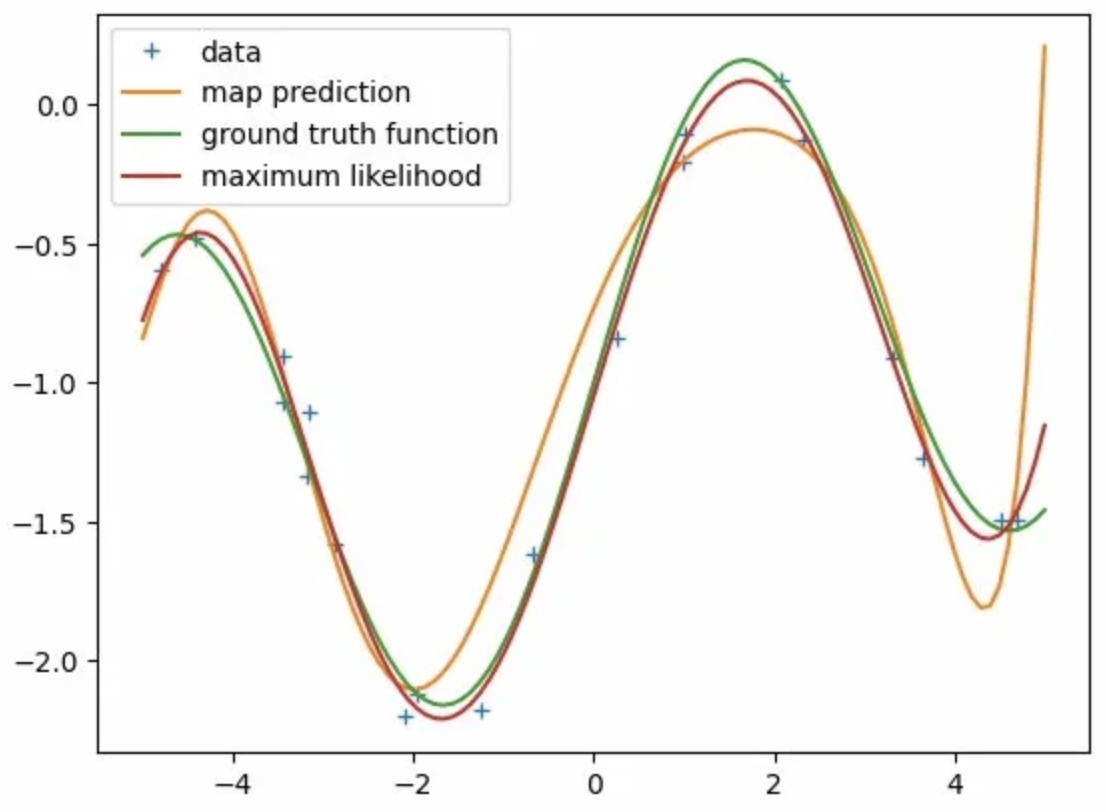



- Large alpha (e.g. 100): prior is almost absent, MAP and MLE become nearly
identical - both explode at the edges and completely miss the ground truth.
The regularisation effect has disappeared entirely.
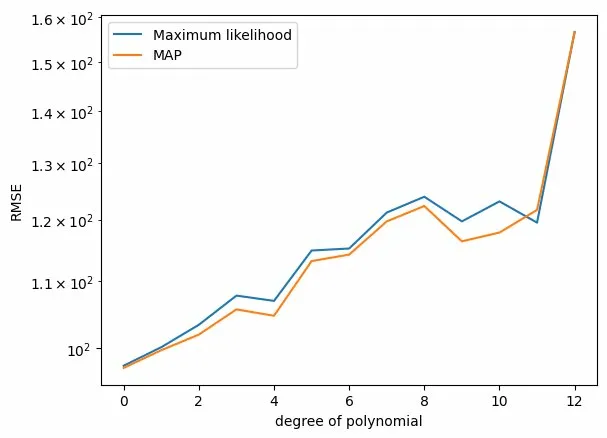

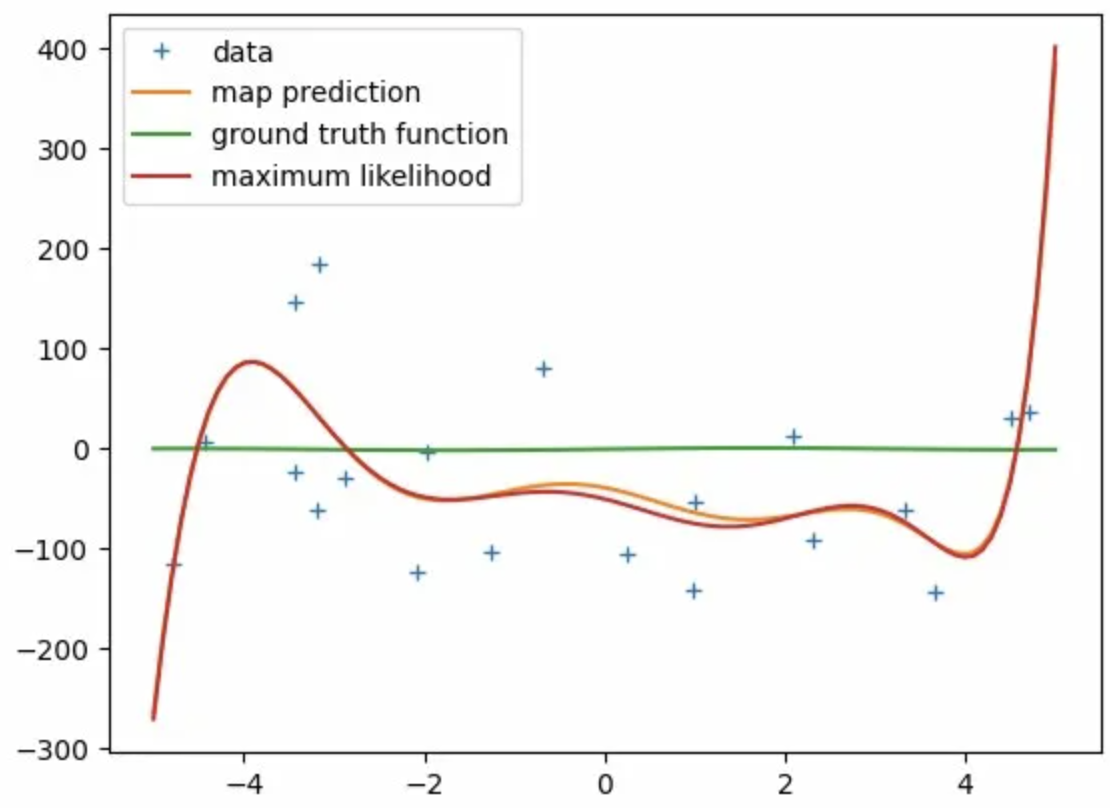

- alpha=1.0: balanced - MAP stays close to MLE at low K but is protected
from explosive overfitting at high K, giving consistently lower test RMSE. (Images already shown in code cell outputs)

## 3. Bayesian Linear Regression

In [32]:
# Test inputs
Ntest = 200
Xtest = np.linspace(-5, 5, Ntest).reshape(-1,1) # test inputs

prior_var = 2.0 # variance of the parameter prior (alpha^2). We assume this is known.
noise_var = 1.0 # noise variance (sigma^2). We assume this is known.

pol_deg = 3 # degree of the polynomial we consider at the moment

Assume a parameter prior $p(\boldsymbol\theta) =  N (\boldsymbol 0, \alpha^2\boldsymbol I)$. For every test input $\boldsymbol x_*$ we obtain the
prior mean
$$
E[f(\boldsymbol x_*)] = 0
$$
and the prior (marginal) variance (ignoring the noise contribution)
$$
V[f(\boldsymbol x_*)] = \alpha^2\boldsymbol\phi(\boldsymbol x_*) \boldsymbol\phi(\boldsymbol x_*)^\top
$$
where $\boldsymbol\phi(\cdot)$ is the feature map.

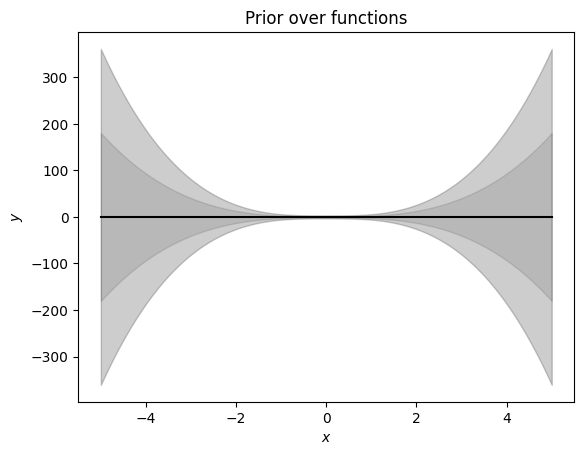

In [33]:
## EDIT THIS CELL

# compute the feature matrix for the test inputs
Phi_test = poly_features(Xtest, pol_deg)  # N x (pol_deg+1) feature matrix <--- EDIT THIS LINE

# compute the (marginal) prior at the test input locations
# prior mean
prior_mean = np.zeros((Ntest,1))  # prior mean at test inputs <-- EDIT THIS LINE

# prior variance
full_covariance = prior_var * Phi_test @ Phi_test.T  # N x N covariance matrix <-- EDIT THIS LINE
prior_marginal_var = np.diag(full_covariance) # marginal of size (N, )

# Let us visualize the prior over functions
plt.figure()
plt.plot(Xtest, prior_mean, color="k")

conf_bound1 = np.sqrt(prior_marginal_var).flatten()
conf_bound2 = 2.0*np.sqrt(prior_marginal_var).flatten()
conf_bound3 = 2.0*np.sqrt(prior_marginal_var + noise_var).flatten()
plt.fill_between(Xtest.flatten(), prior_mean.flatten() + conf_bound1,
             prior_mean.flatten() - conf_bound1, alpha = 0.1, color="k")
plt.fill_between(Xtest.flatten(), prior_mean.flatten() + conf_bound2,
                 prior_mean.flatten() - conf_bound2, alpha = 0.1, color="k")
plt.fill_between(Xtest.flatten(), prior_mean.flatten() + conf_bound3,
                 prior_mean.flatten() - conf_bound3, alpha = 0.1, color="k")

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title("Prior over functions")
plt.show()

Now, we will use this prior distribution and sample functions from it.

Every sampled function is a polynomial of degree 3


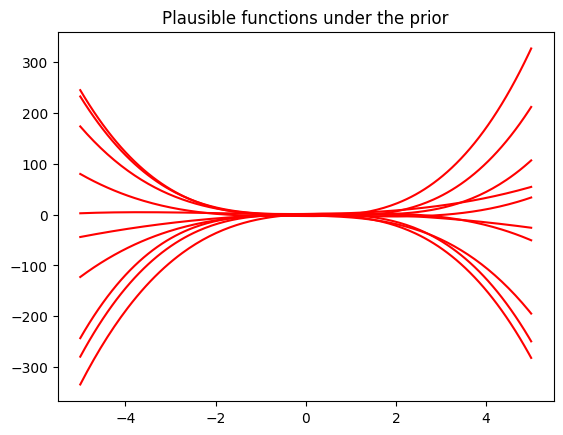

In [34]:
## EDIT THIS CELL

# samples from the prior
num_samples = 10

# We first need to generate random weights theta_i, which we sample from the parameter prior
random_weights = np.random.normal(size=(pol_deg+1,num_samples), scale=np.sqrt(prior_var))

# Now, we compute the induced random functions, evaluated at the test input locations
# Every function sample is given as f_i = Phi * theta_i,
# where theta_i is a sample from the parameter prior

sample_function = Phi_test @ random_weights  # <-- EDIT THIS LINE

plt.figure()
plt.plot(Xtest, sample_function, color="r")
plt.title("Plausible functions under the prior")
print("Every sampled function is a polynomial of degree "+str(pol_deg))
plt.show()

Now we are given some training inputs $\boldsymbol x_1, \dotsc, \boldsymbol x_N$, which we collect in a matrix $\boldsymbol X = [\boldsymbol x_1, \dotsc, \boldsymbol x_N]^\top\in\mathbb{R}^{N\times D}$

In [35]:
N = 10
X = np.random.uniform(high=5, low=-5, size=(N,1)) # training inputs, size Nx1
y = g(X, np.sqrt(noise_var)) # training targets, size Nx1

Now, let us compute the posterior

In [36]:
## EDIT THIS FUNCTION

def polyfit(X, y, K, prior_var, noise_var):
    # X: training inputs, size N x D
    # y: training targets, size N x 1
    # K: degree of polynomial we consider
    # prior_var: prior variance of the parameter distribution
    # sigma: noise variance

    N = X.shape[0] # number of training inputs

    # Compute feature matrix
    Phi = poly_features(X, K) # N x (K+1) feature matrix

    # Compute maximum likelihood estimate
    theta_ml = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)  # <-- EDIT THIS LINE

    # Compute MAP estimate
    theta_map = np.linalg.solve(Phi.T @ Phi + (noise_var/prior_var) * np.eye(K+1), Phi.T @ y)  # <-- EDIT THIS LINE

    # Parameter posterior
    So = prior_var * np.eye(K+1)  # <-- EDIT THIS LINE
    mo = np.zeros((K+1,1))
    SN = np.linalg.inv((1.0/prior_var) * np.eye(K+1) + (1.0/noise_var) * Phi.T @ Phi)  # <-- EDIT THIS LINE
    mN = SN @ ((1.0/noise_var) * Phi.T @ y)  # <-- EDIT THIS LINE

    return (theta_ml, theta_map, mN, SN)

In [37]:
theta_ml, theta_map, theta_mean, theta_var = polyfit(X, y, pol_deg, alpha**2, sigma**2)

Now, let's make predictions (ignoring the measurement noise). We obtain three predictors:
\begin{align}
&\text{Maximum likelihood: }E[f(\boldsymbol X_{\text{test}})] = \boldsymbol \phi(X_{\text{test}})\boldsymbol \theta_{ml}\\
&\text{Maximum a posteriori: } E[f(\boldsymbol X_{\text{test}})] = \boldsymbol \phi(X_{\text{test}})\boldsymbol \theta_{map}\\
&\text{Bayesian: } p(f(\boldsymbol X_{\text{test}})) =  N(f(\boldsymbol X_{\text{test}}) \,|\, \boldsymbol \phi(X_{\text{test}}) \boldsymbol\theta_{\text{mean}},\, \boldsymbol\phi(X_{\text{test}}) \boldsymbol\theta_{\text{var}}  \boldsymbol\phi(X_{\text{test}})^\top)
\end{align}
We already computed all quantities. Write some code that implements all three predictors.

In [38]:
# predictions (ignoring the measurement/observations noise)
Phi_test = poly_features(Xtest, pol_deg) # N x (K+1) feature matrix

# maximum likelihood predictions (just the mean)
m_mle_test = Phi_test @ theta_ml

# MAP predictions (just the mean)
m_map_test = Phi_test @ theta_map

# Bayesian predictions

# predictive distribution (Bayesian linear regression)
# mean prediction
mean_blr = Phi_test @ theta_mean
# variance prediction
cov_blr =  Phi_test @ theta_var @ Phi_test.T

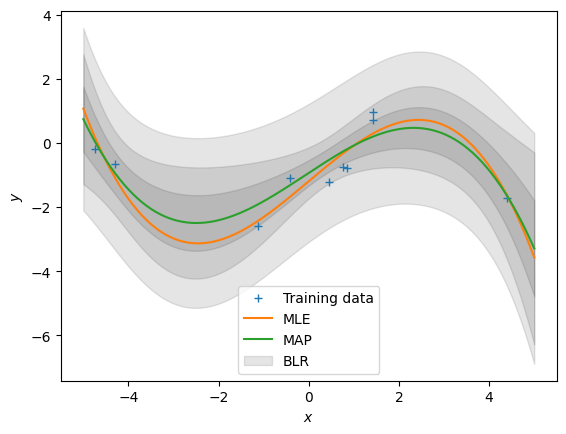

In [39]:
# plot the posterior
plt.figure()
plt.plot(X, y, "+")
plt.plot(Xtest, m_mle_test)
plt.plot(Xtest, m_map_test)
var_blr = np.diag(cov_blr)
conf_bound1 = np.sqrt(var_blr).flatten()
conf_bound2 = 2.0*np.sqrt(var_blr).flatten()
conf_bound3 = 2.0*np.sqrt(var_blr + sigma).flatten()

plt.fill_between(Xtest.flatten(), mean_blr.flatten() + conf_bound1,
                 mean_blr.flatten() - conf_bound1, alpha = 0.1, color="k")
plt.fill_between(Xtest.flatten(), mean_blr.flatten() + conf_bound2,
                 mean_blr.flatten() - conf_bound2, alpha = 0.1, color="k")
plt.fill_between(Xtest.flatten(), mean_blr.flatten() + conf_bound3,
                 mean_blr.flatten() - conf_bound3, alpha = 0.1, color="k")
plt.legend(["Training data", "MLE", "MAP", "BLR"])
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()